In [1]:
import random
import time
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path

random.seed(42)
np.random.seed(42)

print("All imports OK")

All imports OK


In [2]:




MODES = {
    'Cargo Bike': {
        'mode_name'                 : 'Cargo Bike',
        'max_payload_kg'            : 300,
        'max_parcels_per_day'       : 39,
        'stops_per_trip'            : 13,
        'trips_per_day'             : 3,
        'max_service_radius_km'     : 6,
        'speed_kmh'                 : 25,
        'parcels_per_stop'          : 1,
        'emission_factor_co2_per_km': 0.0155,
        'cost_per_km'               : 0.25,
    },
    'E-Van': {
        'mode_name'                 : 'E-Van',
        'max_payload_kg'            : 1000,
        'max_parcels_per_day'       : 160,
        'stops_per_trip'            : 40,
        'trips_per_day'             : 2,
        'max_service_radius_km'     : 30,
        'speed_kmh'                 : 50,
        'parcels_per_stop'          : 2,
        'emission_factor_co2_per_km': 0.1575,
        'cost_per_km'               : 0.70,
    },
    'Truck': {
        'mode_name'                 : 'Truck',
        'max_payload_kg'            : 1200,
        'max_parcels_per_day'       : 125,
        'stops_per_trip'            : 25,
        'trips_per_day'             : 1,
        'max_service_radius_km'     : 40,
        'speed_kmh'                 : 40,
        'parcels_per_stop'          : 5,
        'emission_factor_co2_per_km': 0.3235,
        'cost_per_km'               : 1.20,
    },
}

# Quick sanity check
for name, p in MODES.items():
    print(f"{name}: max_radius={p['max_service_radius_km']}km | "
          f"max_parcels/day={p['max_parcels_per_day']} | "
          f"cost/km=${p['cost_per_km']}")

Cargo Bike: max_radius=6km | max_parcels/day=39 | cost/km=$0.25
E-Van: max_radius=30km | max_parcels/day=160 | cost/km=$0.7
Truck: max_radius=40km | max_parcels/day=125 | cost/km=$1.2


In [3]:
# Dispatch center — Midtown Manhattan
ORIGIN_LAT = 40.7589
ORIGIN_LON = -73.9851

# Load network (cached after first run)
print("Loading Manhattan bike network...")
G = ox.graph_from_place("Manhattan, New York, USA", network_type="bike")
origin_node = ox.nearest_nodes(G, ORIGIN_LON, ORIGIN_LAT)

print(f"Network loaded: {G.number_of_nodes():,} nodes | {G.number_of_edges():,} edges")
print(f"Origin node: {origin_node}")

Loading Manhattan bike network...
Network loaded: 7,259 nodes | 15,072 edges
Origin node: 42439990


In [4]:
import os

# Check what's in your project folder
for f in os.listdir("."):
    print(f)

03_multimodal_routing.ipynb
01_exp_setup.ipynb
cache
breakpoint_results.csv
02_cargo_bike_routing.ipynb
breakpoint_curves_full.png
breakpoint_curves.png
.ipynb_checkpoints
breakpoint_results_full.csv
04_BREAKPOINT_ANALYSIS.ipynb


In [5]:
RESTAURANTS_PATH = (
    "/Users/kaniskaams/Desktop/Routing Last Mile/Project---LMD/"
    "Cleaned Data/restaurants.geojson"
)

print("Loading restaurants...")
restaurants = gpd.read_file(RESTAURANTS_PATH)

if restaurants.crs is None or restaurants.crs.to_epsg() != 4326:
    restaurants = restaurants.set_crs(4326)

print(f"Total restaurants loaded: {len(restaurants):,}")
print(restaurants.geometry.head(3))

Loading restaurants...
Total restaurants loaded: 21,426
0    POINT (-73.98754 40.75054)
1    POINT (-73.98367 40.68803)
2    POINT (-73.98439 40.68044)
Name: geometry, dtype: geometry


In [6]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))


def generate_demand(n_stops, pool_radius_km=15, seed=42):
    """
    Sample n_stops restaurants within pool_radius_km of dispatch center.
    Returns a GeoDataFrame with delivery_id, distance_km, parcel_weight.
    """
    gdf = restaurants.copy()
    gdf['distance_km'] = gdf.apply(
        lambda r: haversine_km(ORIGIN_LAT, ORIGIN_LON,
                               r.geometry.y, r.geometry.x), axis=1
    )
    pool = gdf[gdf['distance_km'] <= pool_radius_km].copy()
    sample = pool.sample(n_stops, random_state=seed).reset_index(drop=True)
    sample['delivery_id']   = [f"D{i:04d}" for i in range(len(sample))]
    sample['parcel_weight'] = np.random.default_rng(seed).normal(5.0, 1.5, len(sample)).clip(1.0)
    return sample[['delivery_id', 'distance_km', 'parcel_weight', 'geometry']]


# Quick test
test = generate_demand(25)
print(f"Generated {len(test)} stops")
print(f"Distance range: {test['distance_km'].min():.2f} - {test['distance_km'].max():.2f} km")
print(f"Weight range:   {test['parcel_weight'].min():.2f} - {test['parcel_weight'].max():.2f} kg")

Generated 25 stops
Distance range: 0.43 - 14.80 km
Weight range:   2.07 - 6.83 kg


In [7]:
def split_into_trips(chromosome, deliveries_df, mode):
    """
    Split a chromosome (ordered list of delivery IDs) into valid trips.
    
    Respects:
    - max_service_radius_km  → stops too far go to out_of_range
    - max_payload_kg         → cumulative weight per trip
    - stops_per_trip         → max stops per trip
    - trips_per_day          → max trips per day
    - max_parcels_per_day    → daily parcel ceiling
    """
    max_radius  = mode['max_service_radius_km']
    max_payload = mode['max_payload_kg']
    max_stops   = mode['stops_per_trip']
    max_trips   = mode['trips_per_day']
    max_parcels = mode['max_parcels_per_day']
    pps         = mode['parcels_per_stop']

    id_to_dist   = deliveries_df.set_index('delivery_id')['distance_km'].to_dict()
    id_to_weight = deliveries_df.set_index('delivery_id')['parcel_weight'].to_dict()

    # Separate out-of-range stops immediately
    out_of_range = [s for s in chromosome if id_to_dist.get(s, 999) > max_radius]
    eligible     = [s for s in chromosome if id_to_dist.get(s, 999) <= max_radius]

    trips          = []
    current_trip   = []
    current_weight = 0.0
    total_parcels  = 0

    for sid in eligible:
        if len(trips) >= max_trips:
            break
        if total_parcels + pps > max_parcels:
            break

        w = id_to_weight.get(sid, 5.0)

        # Start a new trip if current one is full
        if len(current_trip) >= max_stops or current_weight + w > max_payload:
            if current_trip:
                trips.append(current_trip)
                current_trip   = []
                current_weight = 0.0
            if len(trips) >= max_trips:
                break

        current_trip.append(sid)
        current_weight += w
        total_parcels  += pps

    if current_trip and len(trips) < max_trips:
        trips.append(current_trip)

    served   = {s for trip in trips for s in trip}
    unserved = [s for s in eligible if s not in served]

    return trips, unserved, out_of_range, total_parcels


# Quick test on cargo bike with 25 stops
test_chrom = list(test['delivery_id'])
trips, unserved, out_of_range, total_parcels = split_into_trips(
    test_chrom, test, MODES['Cargo Bike']
)

print(f"Cargo Bike on 25 stops:")
print(f"  Trips formed:   {len(trips)}")
print(f"  Stops served:   {sum(len(t) for t in trips)}")
print(f"  Out of range:   {len(out_of_range)}  (beyond 6km)")
print(f"  Unserved:       {len(unserved)}  (in range but couldn't fit)")
print(f"  Total parcels:  {total_parcels}")

Cargo Bike on 25 stops:
  Trips formed:   2
  Stops served:   15
  Out of range:   10  (beyond 6km)
  Unserved:       0  (in range but couldn't fit)
  Total parcels:  15


In [8]:
def precompute_nodes(deliveries_df):
    """Pre-compute OSMnx nearest nodes for all stops. Run once per demand set."""
    nodes = {}
    for _, row in deliveries_df.iterrows():
        nodes[row['delivery_id']] = ox.nearest_nodes(G, row.geometry.x, row.geometry.y)
    return nodes


def calculate_fitness(chromosome, deliveries_df, mode, cached_nodes):
    """
    Evaluate one chromosome (route sequence) for a given mode.
    Returns dict with fitness score and all key metrics.
    """
    trips, unserved, out_of_range, total_parcels = split_into_trips(
        chromosome, deliveries_df, mode
    )

    total_dist = total_cost = total_emissions = 0.0

    for trip in trips:
        trip_dist = 0.0
        prev_node = origin_node

        for sid in trip:
            dest_node = cached_nodes[sid]
            try:
                trip_dist += nx.shortest_path_length(
                    G, prev_node, dest_node, weight='length'
                ) / 1000
            except nx.NetworkXNoPath:
                row = deliveries_df[deliveries_df['delivery_id'] == sid].iloc[0]
                trip_dist += row['distance_km'] * 1.3
            prev_node = dest_node

        # Return to depot
        try:
            trip_dist += nx.shortest_path_length(
                G, prev_node, origin_node, weight='length'
            ) / 1000
        except nx.NetworkXNoPath:
            pass

        total_dist      += trip_dist
        total_cost      += trip_dist * mode['cost_per_km']
        total_emissions += trip_dist * mode['emission_factor_co2_per_km']

    # Penalise ALL undelivered stops (both unserved + out_of_range)
    n_undelivered    = len(unserved) + len(out_of_range)
    unserved_penalty = n_undelivered * 10
    fitness_score    = total_cost + (total_emissions * 2.0) + unserved_penalty

    n_total  = len(chromosome)
    n_served = sum(len(t) for t in trips)

    return {
        'fitness'          : round(fitness_score, 3),
        'total_distance_km': round(total_dist, 3),
        'total_cost'       : round(total_cost, 3),
        'total_emissions'  : round(total_emissions, 3),
        'trips_used'       : len(trips),
        'stops_served'     : n_served,
        'stops_unserved'   : n_undelivered,
        'service_rate'     : round(n_served / n_total * 100, 1) if n_total else 0,
        'total_parcels'    : total_parcels,
    }


# Quick test
cached_test = precompute_nodes(test)
result = calculate_fitness(list(test['delivery_id']), test, MODES['Cargo Bike'], cached_test)

print(f"Cargo Bike fitness test on 25 stops:")
print(f"  Fitness:      {result['fitness']}")
print(f"  Service rate: {result['service_rate']}%")
print(f"  Undelivered:  {result['stops_unserved']}")
print(f"  Cost:         ${result['total_cost']}")

Cargo Bike fitness test on 25 stops:
  Fitness:      124.309
  Service rate: 60.0%
  Undelivered:  10
  Cost:         $21.627


In [9]:
def tournament_select(population, scores, k=4):
    """Pick k random chromosomes, return the one with lowest fitness."""
    candidates = random.sample(range(len(population)), k)
    return population[min(candidates, key=lambda i: scores[i])].copy()


def order_crossover(parent1, parent2):
    """OX1 crossover — preserves relative order of genes from both parents."""
    n = len(parent1)
    a, b = sorted(random.sample(range(n), 2))
    child = [None] * n
    child[a:b] = parent1[a:b]
    fill = [g for g in parent2 if g not in child[a:b]]
    idx = 0
    for i in range(n):
        if child[i] is None:
            child[i] = fill[idx]
            idx += 1
    return child


def mutate(chromosome, rate=0.15):
    """Swap mutation + reverse segment mutation."""
    chrom = chromosome.copy()
    if random.random() < rate:
        # Swap two random stops
        i, j = random.sample(range(len(chrom)), 2)
        chrom[i], chrom[j] = chrom[j], chrom[i]
    if random.random() < rate:
        # Reverse a random segment
        i, j = sorted(random.sample(range(len(chrom)), 2))
        chrom[i:j] = chrom[i:j][::-1]
    return chrom


print("GA operators defined: tournament_select, order_crossover, mutate")

GA operators defined: tournament_select, order_crossover, mutate


In [10]:
def run_ga(deliveries_df, mode, cached_nodes,
           pop_size=60, n_gens=50, elite_size=5,
           cx_rate=0.85, mut_rate=0.15):
    """
    Run genetic algorithm for one mode on one demand set.
    Returns the best result found.
    """
    genes = list(deliveries_df['delivery_id'])
    n     = len(genes)

    # Initialise random population
    population = [random.sample(genes, n) for _ in range(pop_size)]

    # Evaluate initial population
    scores  = [calculate_fitness(c, deliveries_df, mode, cached_nodes)['fitness']
               for c in population]

    best_chrom = population[np.argmin(scores)].copy()
    best_score = min(scores)

    for gen in range(n_gens):
        new_population = []

        # Elitism — carry best chromosomes forward unchanged
        elite_idx = np.argsort(scores)[:elite_size]
        for i in elite_idx:
            new_population.append(population[i].copy())

        # Fill rest of population with crossover + mutation
        while len(new_population) < pop_size:
            p1 = tournament_select(population, scores)
            p2 = tournament_select(population, scores)
            child = order_crossover(p1, p2) if random.random() < cx_rate else p1.copy()
            child = mutate(child, mut_rate)
            new_population.append(child)

        population = new_population
        scores     = [calculate_fitness(c, deliveries_df, mode, cached_nodes)['fitness']
                      for c in population]

        if min(scores) < best_score:
            best_score = min(scores)
            best_chrom = population[np.argmin(scores)].copy()

    # Return full metrics for best chromosome found
    return calculate_fitness(best_chrom, deliveries_df, mode, cached_nodes)


# Quick test — cargo bike, 25 stops, 50 generations
print("Testing GA on Cargo Bike, 25 stops...")
start = time.time()
result = run_ga(test, MODES['Cargo Bike'], cached_test)
elapsed = time.time() - start

print(f"  Done in {elapsed:.1f}s")
print(f"  Fitness:      {result['fitness']}")
print(f"  Service rate: {result['service_rate']}%")
print(f"  Distance:     {result['total_distance_km']} km")
print(f"  Cost:         ${result['total_cost']}")

Testing GA on Cargo Bike, 25 stops...
  Done in 76.7s
  Fitness:      109.727
  Service rate: 60.0%
  Distance:     34.615 km
  Cost:         $8.654


In [11]:
def precompute_distance_matrix(deliveries_df, cached_nodes):
    """
    Pre-compute road distances between ALL pairs of stops + origin.
    Runs once per demand set. Makes GA ~50x faster.
    """
    ids       = list(deliveries_df['delivery_id'])
    all_nodes = [origin_node] + [cached_nodes[sid] for sid in ids]
    all_ids   = ['ORIGIN'] + ids
    n         = len(all_nodes)

    print(f"  Computing {n}x{n} distance matrix ({n*n} pairs)...")
    dist_matrix = {}

    for i, (id_i, node_i) in enumerate(zip(all_ids, all_nodes)):
        # Compute shortest paths FROM node_i to all other nodes at once
        lengths = nx.single_source_dijkstra_path_length(G, node_i, weight='length')
        for j, (id_j, node_j) in enumerate(zip(all_ids, all_nodes)):
            dist_matrix[(id_i, id_j)] = lengths.get(node_j, None)

    # Convert from metres to km
    dist_matrix = {k: (v / 1000 if v is not None else None)
                   for k, v in dist_matrix.items()}

    print(f"  Done. {len(dist_matrix)} distances cached.")
    return dist_matrix


# Test on 25 stops
print("Pre-computing distance matrix for 25 stops...")
start = time.time()
dist_matrix_test = precompute_distance_matrix(test, cached_test)
elapsed = time.time() - start
print(f"Completed in {elapsed:.1f}s")

# Spot check
sample_id = test['delivery_id'].iloc[0]
print(f"\nDistance ORIGIN → {sample_id}: {dist_matrix_test[('ORIGIN', sample_id)]:.3f} km")
print(f"Distance {sample_id} → ORIGIN: {dist_matrix_test[(sample_id, 'ORIGIN')]:.3f} km")

Pre-computing distance matrix for 25 stops...
  Computing 26x26 distance matrix (676 pairs)...
  Done. 676 distances cached.
Completed in 0.2s

Distance ORIGIN → D0000: 6.300 km
Distance D0000 → ORIGIN: 6.295 km


In [12]:
def calculate_fitness_fast(chromosome, deliveries_df, mode, dist_matrix):
    """
    Same logic as calculate_fitness but uses pre-computed distance matrix.
    Instant lookups instead of Dijkstra calls — ~50x faster.
    """
    trips, unserved, out_of_range, total_parcels = split_into_trips(
        chromosome, deliveries_df, mode
    )

    total_dist = total_cost = total_emissions = 0.0

    for trip in trips:
        trip_dist = 0.0
        prev_id   = 'ORIGIN'

        for sid in trip:
            d = dist_matrix.get((prev_id, sid))
            if d is None:
                row = deliveries_df[deliveries_df['delivery_id'] == sid].iloc[0]
                d   = row['distance_km'] * 1.3
            trip_dist += d
            prev_id    = sid

        # Return to depot
        d = dist_matrix.get((prev_id, 'ORIGIN'))
        if d is not None:
            trip_dist += d

        total_dist      += trip_dist
        total_cost      += trip_dist * mode['cost_per_km']
        total_emissions += trip_dist * mode['emission_factor_co2_per_km']

    n_undelivered    = len(unserved) + len(out_of_range)
    unserved_penalty = n_undelivered * 10
    fitness_score    = total_cost + (total_emissions * 2.0) + unserved_penalty

    n_total  = len(chromosome)
    n_served = sum(len(t) for t in trips)

    return {
        'fitness'          : round(fitness_score, 3),
        'total_distance_km': round(total_dist, 3),
        'total_cost'       : round(total_cost, 3),
        'total_emissions'  : round(total_emissions, 3),
        'trips_used'       : len(trips),
        'stops_served'     : n_served,
        'stops_unserved'   : n_undelivered,
        'service_rate'     : round(n_served / n_total * 100, 1) if n_total else 0,
        'total_parcels'    : total_parcels,
    }


# Test speed difference
print("Testing fast fitness function...")
start  = time.time()
result = calculate_fitness_fast(
    list(test['delivery_id']), test, MODES['Cargo Bike'], dist_matrix_test
)
elapsed = time.time() - start

print(f"  Done in {elapsed:.4f}s")
print(f"  Fitness:      {result['fitness']}")
print(f"  Service rate: {result['service_rate']}%")

Testing fast fitness function...
  Done in 0.0008s
  Fitness:      124.309
  Service rate: 60.0%


In [13]:
def run_ga_fast(deliveries_df, mode, dist_matrix,
                pop_size=60, n_gens=50, elite_size=5,
                cx_rate=0.85, mut_rate=0.15):
    """
    GA using pre-computed distance matrix for fast fitness evaluation.
    """
    genes = list(deliveries_df['delivery_id'])
    n     = len(genes)

    population = [random.sample(genes, n) for _ in range(pop_size)]
    scores     = [calculate_fitness_fast(c, deliveries_df, mode, dist_matrix)['fitness']
                  for c in population]

    best_chrom = population[np.argmin(scores)].copy()
    best_score = min(scores)

    for gen in range(n_gens):
        new_population = []

        # Elitism
        elite_idx = np.argsort(scores)[:elite_size]
        for i in elite_idx:
            new_population.append(population[i].copy())

        # Crossover + mutation
        while len(new_population) < pop_size:
            p1    = tournament_select(population, scores)
            p2    = tournament_select(population, scores)
            child = order_crossover(p1, p2) if random.random() < cx_rate else p1.copy()
            child = mutate(child, mut_rate)
            new_population.append(child)

        population = new_population
        scores     = [calculate_fitness_fast(c, deliveries_df, mode, dist_matrix)['fitness']
                      for c in population]

        if min(scores) < best_score:
            best_score = min(scores)
            best_chrom = population[np.argmin(scores)].copy()

    return calculate_fitness_fast(best_chrom, deliveries_df, mode, dist_matrix)


# Test on cargo bike, 25 stops
print("Testing fast GA — Cargo Bike, 25 stops...")
start  = time.time()
result = run_ga_fast(test, MODES['Cargo Bike'], dist_matrix_test)
elapsed = time.time() - start

print(f"  Done in {elapsed:.1f}s")
print(f"  Fitness:      {result['fitness']}")
print(f"  Service rate: {result['service_rate']}%")
print(f"  Distance:     {result['total_distance_km']} km")
print(f"  Cost:         ${result['total_cost']}")


Testing fast GA — Cargo Bike, 25 stops...
  Done in 1.2s
  Fitness:      109.726
  Service rate: 60.0%
  Distance:     34.614 km
  Cost:         $8.653


In [14]:
DEMAND_LEVELS = [25, 50, 100, 200]
results = []

for n_stops in DEMAND_LEVELS:
    print(f"\n{'='*50}")
    print(f"DEMAND LEVEL: {n_stops} stops")
    print(f"{'='*50}")

    # Generate demand set and precompute once for all modes
    deliveries   = generate_demand(n_stops)
    cached_nodes = precompute_nodes(deliveries)

    print(f"  Precomputing distance matrix...")
    start        = time.time()
    dist_matrix  = precompute_distance_matrix(deliveries, cached_nodes)
    print(f"  Distance matrix ready in {time.time()-start:.1f}s")

    for mode_name, mode in MODES.items():
        print(f"\n  Running GA — {mode_name}...")
        start  = time.time()
        result = run_ga_fast(deliveries, mode, dist_matrix)
        elapsed = time.time() - start

        print(f"    Done in {elapsed:.1f}s | "
              f"Service rate: {result['service_rate']}% | "
              f"Fitness: {result['fitness']}")

        results.append({
            'demand_level'     : n_stops,
            'mode'             : mode_name,
            'fitness'          : result['fitness'],
            'service_rate'     : result['service_rate'],
            'total_distance_km': result['total_distance_km'],
            'total_cost'       : result['total_cost'],
            'total_emissions'  : result['total_emissions'],
            'trips_used'       : result['trips_used'],
            'stops_served'     : result['stops_served'],
            'stops_unserved'   : result['stops_unserved'],
        })

# Save to CSV
df = pd.DataFrame(results)
df.to_csv('breakpoint_results.csv', index=False)
print(f"\n{'='*50}")
print(f"SWEEP COMPLETE — results saved to breakpoint_results.csv")
print(f"{'='*50}")
print(df.to_string(index=False))


DEMAND LEVEL: 25 stops
  Precomputing distance matrix...
  Computing 26x26 distance matrix (676 pairs)...
  Done. 676 distances cached.
  Distance matrix ready in 0.2s

  Running GA — Cargo Bike...
    Done in 1.2s | Service rate: 60.0% | Fitness: 109.76

  Running GA — E-Van...
    Done in 1.8s | Service rate: 100.0% | Fitness: 63.793

  Running GA — Truck...
    Done in 1.7s | Service rate: 100.0% | Fitness: 115.965

DEMAND LEVEL: 50 stops
  Precomputing distance matrix...
  Computing 51x51 distance matrix (2601 pairs)...
  Done. 2601 distances cached.
  Distance matrix ready in 0.4s

  Running GA — Cargo Bike...
    Done in 1.1s | Service rate: 54.0% | Fitness: 244.465

  Running GA — E-Van...
    Done in 1.8s | Service rate: 100.0% | Fitness: 132.603

  Running GA — Truck...
    Done in 1.7s | Service rate: 50.0% | Fitness: 337.247

DEMAND LEVEL: 100 stops
  Precomputing distance matrix...
  Computing 101x101 distance matrix (10201 pairs)...
  Done. 10201 distances cached.
  Dista

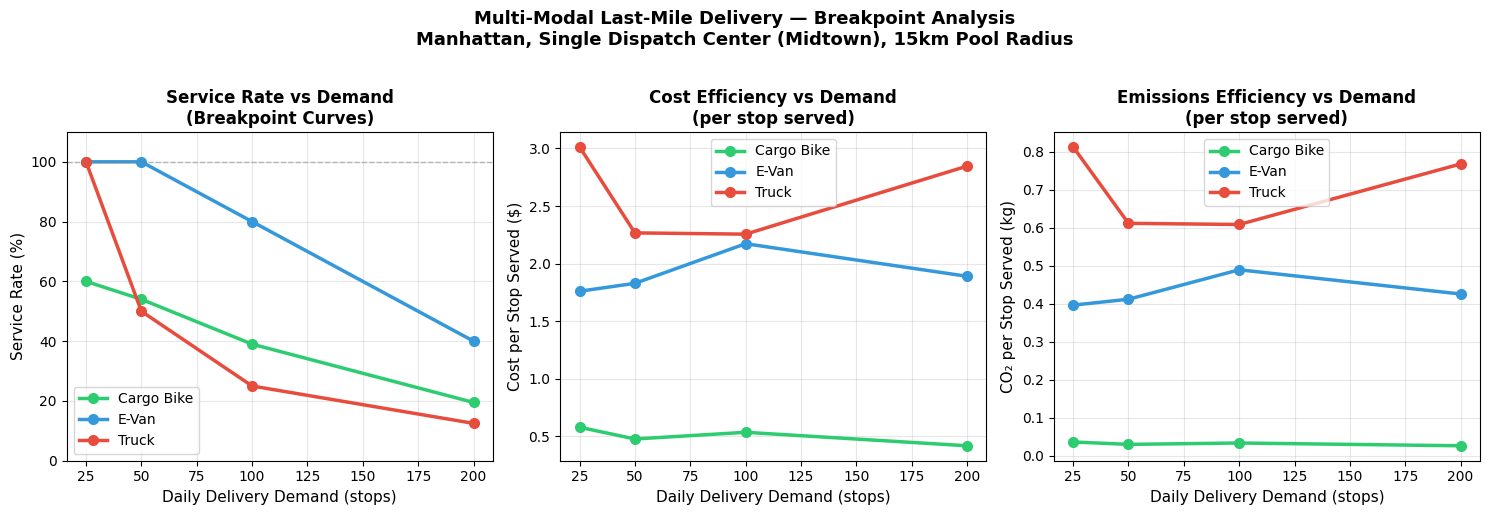

Figure saved: breakpoint_curves.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = {
    'Cargo Bike': '#2ecc71',
    'E-Van'     : '#3498db',
    'Truck'     : '#e74c3c'
}

# ── Plot 1: Service Rate vs Demand ───────────────────────────────────────────
ax = axes[0]
for mode_name in MODES.keys():
    mode_df = df[df['mode'] == mode_name]
    ax.plot(mode_df['demand_level'], mode_df['service_rate'],
            marker='o', linewidth=2.5, markersize=7,
            color=colors[mode_name], label=mode_name)

ax.axhline(y=100, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Daily Delivery Demand (stops)', fontsize=11)
ax.set_ylabel('Service Rate (%)', fontsize=11)
ax.set_title('Service Rate vs Demand\n(Breakpoint Curves)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 110)
ax.grid(True, alpha=0.3)

# ── Plot 2: Cost per Stop Served ─────────────────────────────────────────────
ax = axes[1]
for mode_name in MODES.keys():
    mode_df = df[df['mode'] == mode_name].copy()
    mode_df['cost_per_stop'] = mode_df.apply(
        lambda r: round(r['total_cost'] / r['stops_served'], 3)
        if r['stops_served'] > 0 else None, axis=1
    )
    ax.plot(mode_df['demand_level'], mode_df['cost_per_stop'],
            marker='o', linewidth=2.5, markersize=7,
            color=colors[mode_name], label=mode_name)

ax.set_xlabel('Daily Delivery Demand (stops)', fontsize=11)
ax.set_ylabel('Cost per Stop Served ($)', fontsize=11)
ax.set_title('Cost Efficiency vs Demand\n(per stop served)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── Plot 3: Emissions per Stop Served ────────────────────────────────────────
ax = axes[2]
for mode_name in MODES.keys():
    mode_df = df[df['mode'] == mode_name].copy()
    mode_df['emissions_per_stop'] = mode_df.apply(
        lambda r: round(r['total_emissions'] / r['stops_served'], 4)
        if r['stops_served'] > 0 else None, axis=1
    )
    ax.plot(mode_df['demand_level'], mode_df['emissions_per_stop'],
            marker='o', linewidth=2.5, markersize=7,
            color=colors[mode_name], label=mode_name)

ax.set_xlabel('Daily Delivery Demand (stops)', fontsize=11)
ax.set_ylabel('CO₂ per Stop Served (kg)', fontsize=11)
ax.set_title('Emissions Efficiency vs Demand\n(per stop served)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle(
    'Multi-Modal Last-Mile Delivery — Breakpoint Analysis\n'
    'Manhattan, Single Dispatch Center (Midtown), 15km Pool Radius',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('breakpoint_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: breakpoint_curves.png")

In [16]:
print(df.shape)
print(df.columns.tolist())
print(df['mode'].unique())

(12, 10)
['demand_level', 'mode', 'fitness', 'service_rate', 'total_distance_km', 'total_cost', 'total_emissions', 'trips_used', 'stops_served', 'stops_unserved']
['Cargo Bike' 'E-Van' 'Truck']


In [17]:
# Does cargo bike's 6km radius cover a realistic Manhattan area?
within_6km = test[test['distance_km'] <= 6]
beyond_6km = test[test['distance_km'] > 6]

print(f"Within 6km (cargo bike reachable): {len(within_6km)} stops")
print(f"Beyond 6km (out of range):         {len(beyond_6km)} stops")
print(f"\nE-Van reachable (within 30km):     {len(test[test['distance_km'] <= 30])} stops")
print(f"Truck reachable (within 40km):     {len(test[test['distance_km'] <= 40])} stops")

Within 6km (cargo bike reachable): 15 stops
Beyond 6km (out of range):         10 stops

E-Van reachable (within 30km):     25 stops
Truck reachable (within 40km):     25 stops


In [18]:
DEMAND_LEVELS_FULL = [25, 50, 75, 100, 125, 150, 175, 200]
results_full = []

for n_stops in DEMAND_LEVELS_FULL:
    print(f"\n{'='*50}")
    print(f"DEMAND LEVEL: {n_stops} stops")
    print(f"{'='*50}")

    deliveries   = generate_demand(n_stops)
    cached_nodes = precompute_nodes(deliveries)
    dist_matrix  = precompute_distance_matrix(deliveries, cached_nodes)

    for mode_name, mode in MODES.items():
        result = run_ga_fast(deliveries, mode, dist_matrix)

        print(f"  {mode_name:12s} | "
              f"Service: {result['service_rate']:5.1f}% | "
              f"Cost/stop: ${result['total_cost']/result['stops_served']:.2f} | "
              f"Fitness: {result['fitness']}")

        results_full.append({
            'demand_level'     : n_stops,
            'mode'             : mode_name,
            'fitness'          : result['fitness'],
            'service_rate'     : result['service_rate'],
            'total_distance_km': result['total_distance_km'],
            'total_cost'       : result['total_cost'],
            'total_emissions'  : result['total_emissions'],
            'trips_used'       : result['trips_used'],
            'stops_served'     : result['stops_served'],
            'stops_unserved'   : result['stops_unserved'],
        })

df_full = pd.DataFrame(results_full)
df_full.to_csv('breakpoint_results_full.csv', index=False)
print(f"\nSweep complete — saved to breakpoint_results_full.csv")


DEMAND LEVEL: 25 stops
  Computing 26x26 distance matrix (676 pairs)...
  Done. 676 distances cached.
  Cargo Bike   | Service:  60.0% | Cost/stop: $0.59 | Fitness: 109.891
  E-Van        | Service: 100.0% | Cost/stop: $2.05 | Fitness: 74.428
  Truck        | Service: 100.0% | Cost/stop: $2.65 | Fitness: 102.007

DEMAND LEVEL: 50 stops
  Computing 51x51 distance matrix (2601 pairs)...
  Done. 2601 distances cached.
  Cargo Bike   | Service:  54.0% | Cost/stop: $0.51 | Fitness: 245.599
  E-Van        | Service: 100.0% | Cost/stop: $1.98 | Fitness: 143.654
  Truck        | Service:  50.0% | Cost/stop: $2.57 | Fitness: 348.977

DEMAND LEVEL: 75 stops
  Computing 76x76 distance matrix (5776 pairs)...
  Done. 5776 distances cached.
  Cargo Bike   | Service:  52.0% | Cost/stop: $0.53 | Fitness: 383.018
  E-Van        | Service: 100.0% | Cost/stop: $2.17 | Fitness: 236.425
  Truck        | Service:  33.3% | Cost/stop: $2.16 | Fitness: 582.954

DEMAND LEVEL: 100 stops
  Computing 101x101 dist

In [19]:
# What fraction of the full pool is within cargo bike range?
full_pool = restaurants.copy()
full_pool['distance_km'] = full_pool.apply(
    lambda r: haversine_km(ORIGIN_LAT, ORIGIN_LON,
                           r.geometry.y, r.geometry.x), axis=1
)
within_15km = full_pool[full_pool['distance_km'] <= 15]
within_6km  = full_pool[full_pool['distance_km'] <= 6]

print(f"Restaurants within 15km pool: {len(within_15km):,}")
print(f"Restaurants within 6km (bike reachable): {len(within_6km):,}")
print(f"Geographic ceiling for cargo bike: {len(within_6km)/len(within_15km)*100:.1f}%")

Restaurants within 15km pool: 17,111
Restaurants within 6km (bike reachable): 8,557
Geographic ceiling for cargo bike: 50.0%


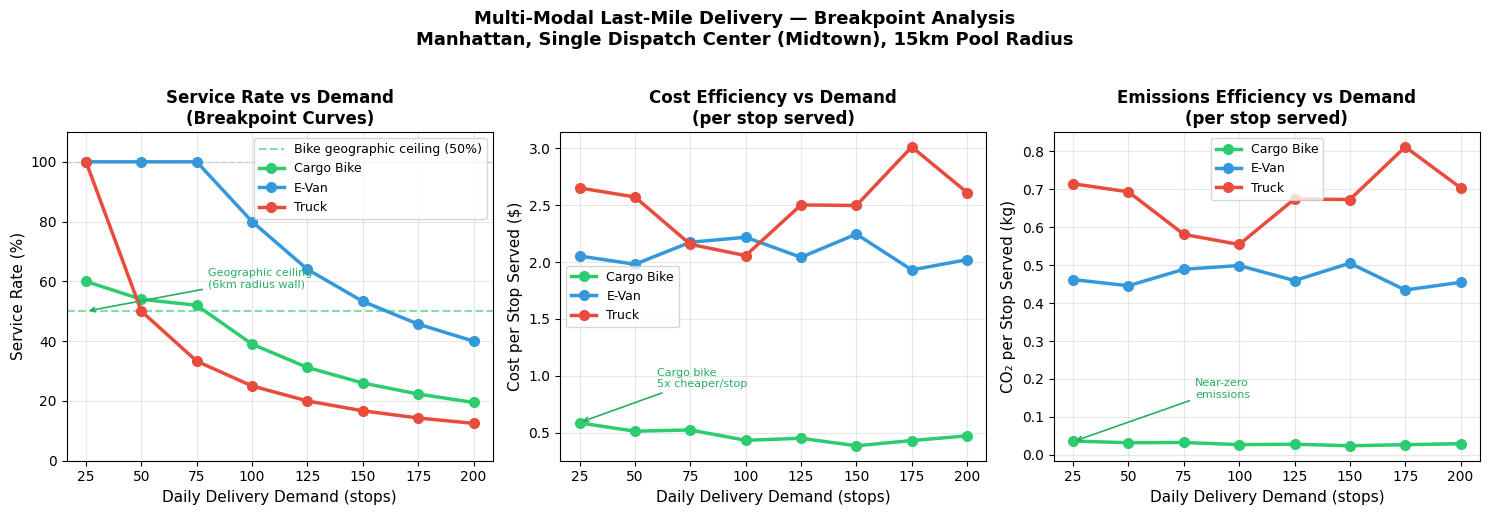

Figure saved: breakpoint_curves_full.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = {
    'Cargo Bike': '#2ecc71',
    'E-Van'     : '#3498db',
    'Truck'     : '#e74c3c'
}

# ── Plot 1: Service Rate vs Demand ───────────────────────────────────────────
ax = axes[0]

# Geographic ceiling line for cargo bike
ax.axhline(y=50, color='#2ecc71', linestyle='--', linewidth=1.5,
           alpha=0.6, label='Bike geographic ceiling (50%)')

for mode_name in MODES.keys():
    mode_df = df_full[df_full['mode'] == mode_name]
    ax.plot(mode_df['demand_level'], mode_df['service_rate'],
            marker='o', linewidth=2.5, markersize=7,
            color=colors[mode_name], label=mode_name)

ax.axhline(y=100, color='gray', linestyle='--', linewidth=1, alpha=0.3)
ax.set_xlabel('Daily Delivery Demand (stops)', fontsize=11)
ax.set_ylabel('Service Rate (%)', fontsize=11)
ax.set_title('Service Rate vs Demand\n(Breakpoint Curves)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 110)
ax.grid(True, alpha=0.3)

# Annotate cargo bike ceiling
ax.annotate('Geographic ceiling\n(6km radius wall)',
            xy=(25, 50), xytext=(80, 58),
            fontsize=8, color='#27ae60',
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.2))

# ── Plot 2: Cost per Stop Served ─────────────────────────────────────────────
ax = axes[1]
for mode_name in MODES.keys():
    mode_df = df_full[df_full['mode'] == mode_name].copy()
    mode_df['cost_per_stop'] = mode_df.apply(
        lambda r: round(r['total_cost'] / r['stops_served'], 3)
        if r['stops_served'] > 0 else None, axis=1
    )
    ax.plot(mode_df['demand_level'], mode_df['cost_per_stop'],
            marker='o', linewidth=2.5, markersize=7,
            color=colors[mode_name], label=mode_name)

ax.set_xlabel('Daily Delivery Demand (stops)', fontsize=11)
ax.set_ylabel('Cost per Stop Served ($)', fontsize=11)
ax.set_title('Cost Efficiency vs Demand\n(per stop served)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Annotate cargo bike advantage
ax.annotate('Cargo bike\n5x cheaper/stop',
            xy=(25, 0.59), xytext=(60, 0.9),
            fontsize=8, color='#27ae60',
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.2))

# ── Plot 3: Emissions per Stop Served ────────────────────────────────────────
ax = axes[2]
for mode_name in MODES.keys():
    mode_df = df_full[df_full['mode'] == mode_name].copy()
    mode_df['emissions_per_stop'] = mode_df.apply(
        lambda r: round(r['total_emissions'] / r['stops_served'], 4)
        if r['stops_served'] > 0 else None, axis=1
    )
    ax.plot(mode_df['demand_level'], mode_df['emissions_per_stop'],
            marker='o', linewidth=2.5, markersize=7,
            color=colors[mode_name], label=mode_name)

ax.set_xlabel('Daily Delivery Demand (stops)', fontsize=11)
ax.set_ylabel('CO₂ per Stop Served (kg)', fontsize=11)
ax.set_title('Emissions Efficiency vs Demand\n(per stop served)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Annotate cargo bike emissions advantage
ax.annotate('Near-zero\nemissions',
            xy=(25, 0.035), xytext=(80, 0.15),
            fontsize=8, color='#27ae60',
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.2))

plt.suptitle(
    'Multi-Modal Last-Mile Delivery — Breakpoint Analysis\n'
    'Manhattan, Single Dispatch Center (Midtown), 15km Pool Radius',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('breakpoint_curves_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: breakpoint_curves_full.png")